# 09 - Model Evaluation & Comparison

This notebook:
- Loads all 6 trained models and test data
- Computes Accuracy, AUC, Precision, Recall, F1, MCC for each
- Creates a comparison table and visualisations
- Identifies the best-performing model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, matthews_corrcoef,
                             confusion_matrix, roc_curve)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load test data
PROCESSED = Path('..') / 'data' / 'processed'
X_test = pd.read_csv(PROCESSED / 'X_test.csv').astype(float)
y_test = pd.read_csv(PROCESSED / 'y_test.csv').values.ravel().astype(int)

# Load all models
MODELS_DIR = Path('..') / 'models'
models = {
    'Logistic Regression': joblib.load(MODELS_DIR / 'logistic_regression.pkl'),
    'Decision Tree': joblib.load(MODELS_DIR / 'decision_tree.pkl'),
    'kNN': joblib.load(MODELS_DIR / 'knn.pkl'),
    'Naive Bayes': joblib.load(MODELS_DIR / 'naive_bayes.pkl'),
    'Random Forest': joblib.load(MODELS_DIR / 'random_forest.pkl'),
    'XGBoost': joblib.load(MODELS_DIR / 'xgboost.pkl'),
}
print(f"Loaded {len(models)} models")

Loaded 6 models


In [2]:
# Compute metrics for all models
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_prob),
        'MCC': matthews_corrcoef(y_test, y_pred),
    })

comparison_df = pd.DataFrame(results).set_index('Model')
comparison_df = comparison_df.round(4)
print("=== Model Comparison Table ===")
comparison_df

=== Model Comparison Table ===


,Accuracy,Precision,Recall,F1,AUC,MCC
Model,,,,,,
Logistic Regression,0.8839,0.9126,0.9592,0.9353,0.8929,0.3848
Decision Tree,0.9286,0.9412,0.9796,0.9600,0.9767,0.6391
kNN,0.9821,0.9800,1.0000,0.9899,0.9271,0.9165
Naive Bayes,0.9196,0.9406,0.9694,0.9548,0.9111,0.6010
Random Forest,0.9732,0.9703,1.0000,0.9849,0.9537,0.8731
XGBoost,0.9732,0.9798,0.9898,0.9848,0.9789,0.8745


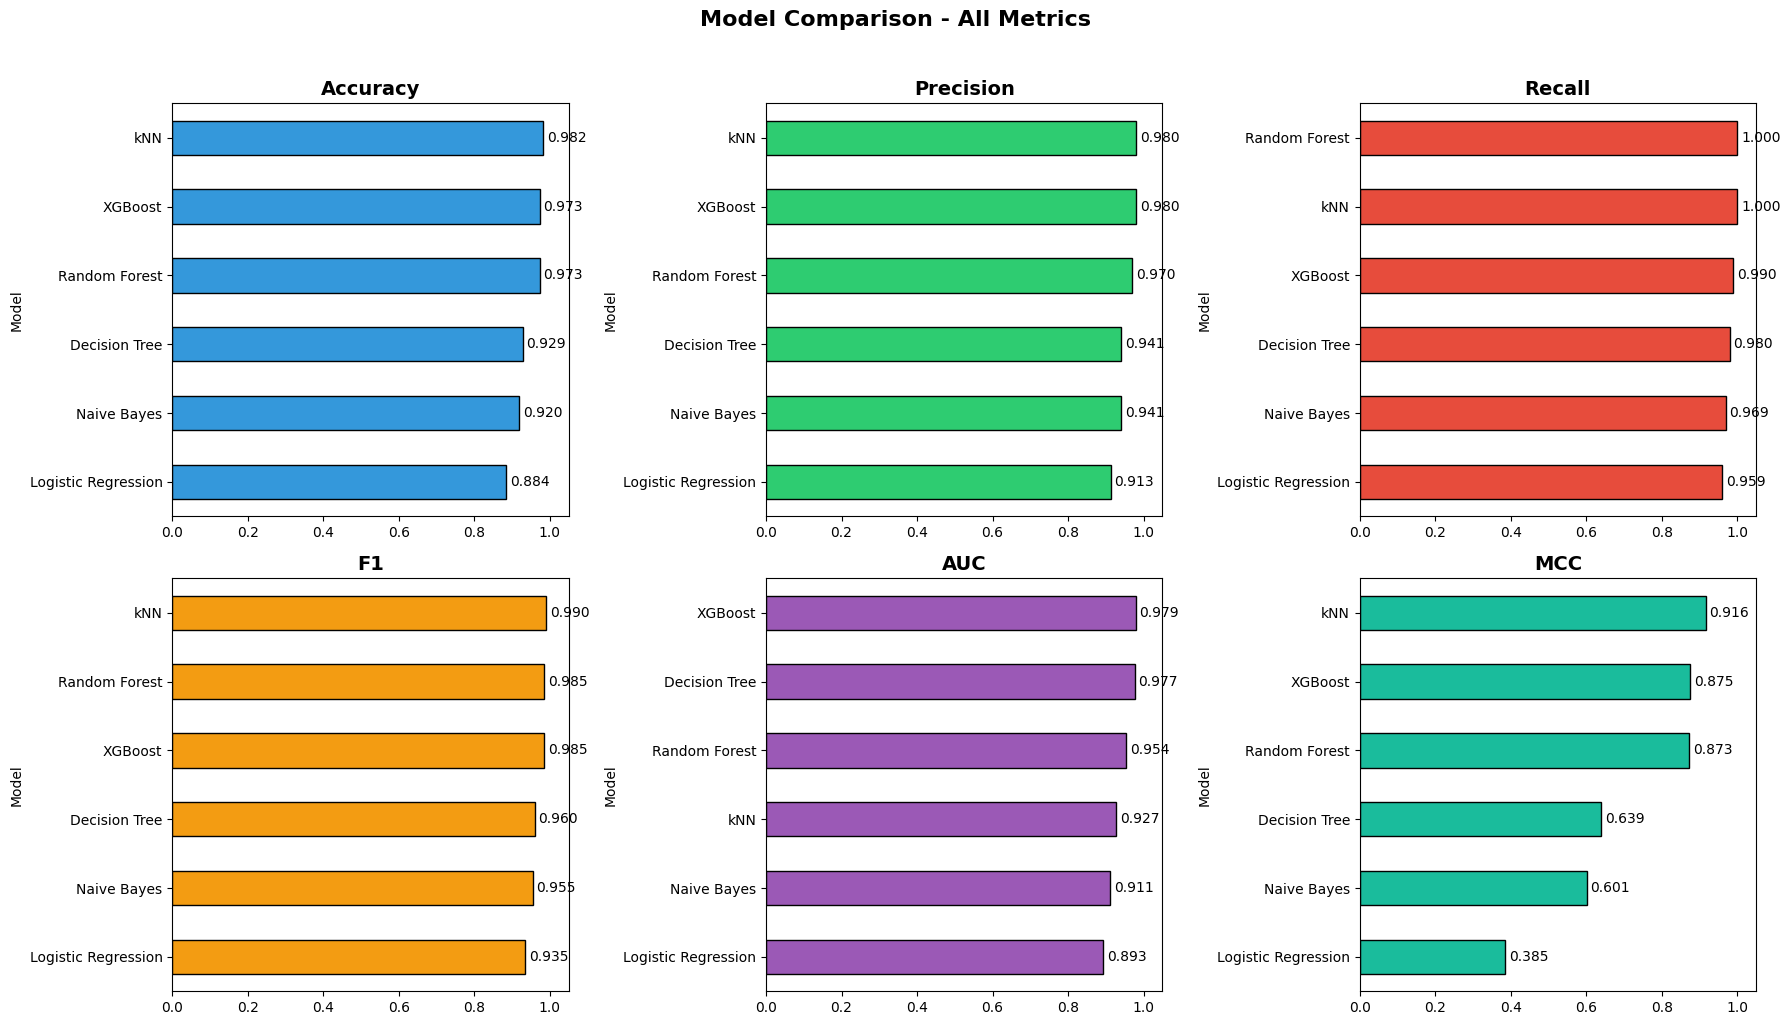

In [3]:
# Bar chart comparison of all metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC', 'MCC']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

for ax, metric, color in zip(axes.flatten(), metrics, colors):
    comparison_df[metric].sort_values().plot(kind='barh', ax=ax, color=color, edgecolor='black')
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1.05)
    for i, v in enumerate(comparison_df[metric].sort_values()):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

plt.suptitle('Model Comparison - All Metrics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

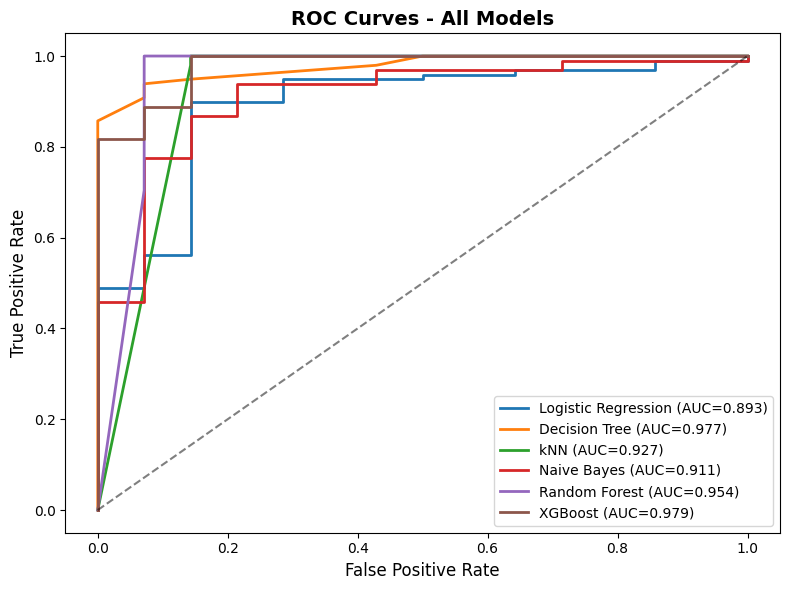

In [4]:
# ROC curves for all models on one plot
plt.figure(figsize=(8, 6))
for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', linewidth=2)

plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('../results/roc_comparison.png', dpi=150)
plt.show()

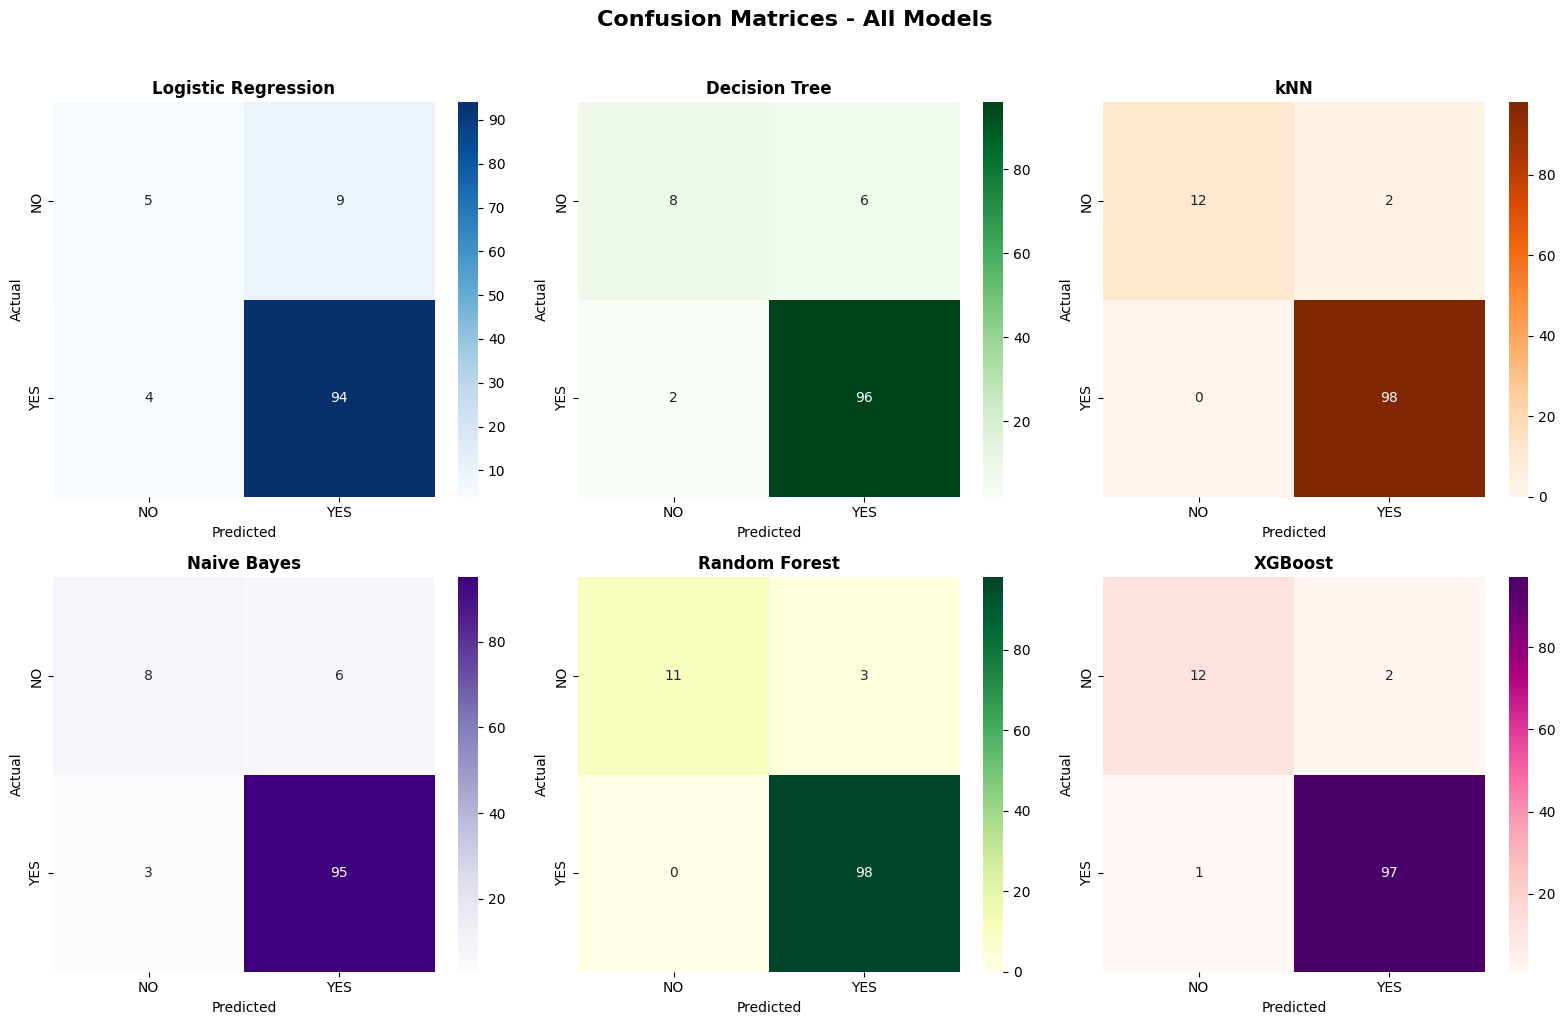

In [5]:
# Confusion matrices side by side
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cmaps = ['Blues', 'Greens', 'Oranges', 'Purples', 'YlGn', 'RdPu']

for ax, (name, model), cmap in zip(axes.flatten(), models.items(), cmaps):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['NO','YES'], yticklabels=['NO','YES'])
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Save final comparison table
RESULTS_DIR = Path('..') / 'results'
comparison_df.to_csv(RESULTS_DIR / 'model_comparison.csv')

# Identify best model
best_model = comparison_df['Accuracy'].idxmax()
print(f"\n Best model by Accuracy: {best_model} ({comparison_df.loc[best_model, 'Accuracy']:.4f})")

best_f1 = comparison_df['F1'].idxmax()
print(f" Best model by F1-Score: {best_f1} ({comparison_df.loc[best_f1, 'F1']:.4f})")

best_auc = comparison_df['AUC'].idxmax()
print(f" Best model by AUC-ROC:  {best_auc} ({comparison_df.loc[best_auc, 'AUC']:.4f})")

print("\n Comparison table saved to results/model_comparison.csv")


 Best model by Accuracy: kNN (0.9821)
 Best model by F1-Score: kNN (0.9899)
 Best model by AUC-ROC:  XGBoost (0.9789)

 Comparison table saved to results/model_comparison.csv
